# XGBoost v4 (scale_pos_weight)

This notebook builds on v3 by:

1. Swapping out compute_sample_weight for scale_pos_weight: **XGBoost's own built-in way to handle imbalance**
2. Everything else stays exactly the same as v3

The idea is scale_pos_weight tells XGBoost directly during training that cancelled flights matter more. In v3 we were doing this from the outside with sklearn. Let's see if doing it inside the model actually works better.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data
Loading the data and building targets. Same as v3, nothing changed here.

In [3]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, FEATURES

df = load_data()
features = [f for f in FEATURES if f in df.columns]

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

X_train, y_train = train[features], train['target'].astype(int)
X_val,   y_val   = val[features],   val['target'].astype(int)
X_test,  y_test  = test[features],  test['target'].astype(int)

if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train.iloc[idx]

neg = (y_train == 0).sum() + (y_train == 1).sum()
pos = (y_train == 2).sum()
scale_pw = round(neg / pos)
print(f'not-cancelled: {neg:,} | cancelled: {pos:,} | scale_pos_weight = {scale_pw}')
print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

not-cancelled: 13,535,123 | cancelled: 241,978 | scale_pos_weight = 56
train: (13777101, 18), val: (6310951, 18), test: (4077639, 18)


## Training

Same params as v1-v3. The only thing we're changing is passing the cancelled class weight through sample_weight so XGBoost upweights it during training.

In [4]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

# for multiclass we use sample_weight with the cancelled class weighted up
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(
    class_weight={0: 1, 1: 1, 2: scale_pw},  # weight cancelled by scale_pw
    y=y_train
)

model.fit(X_train, y_train,
          sample_weight=sample_weights,
          eval_set=[(X_val, y_val)],
          verbose=False)
print('model done')

model done


## Val Results

val macro F1: 0.2795
              precision    recall  f1-score   support

     on_time       0.84      0.72      0.77   5127027
     delayed       0.48      0.00      0.00   1072910
   cancelled       0.03      0.54      0.06    111014

    accuracy                           0.60   6310951
   macro avg       0.45      0.42      0.28   6310951
weighted avg       0.76      0.60      0.63   6310951



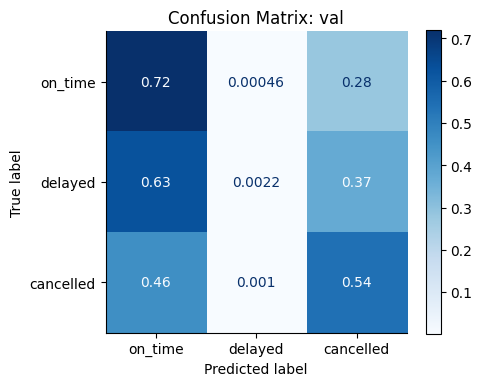

In [5]:
def evaluate(model, X, y_true, label='val'):
    y_pred = model.predict(X)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f'{label} macro F1: {mf1:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
        ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    plt.show()
    return mf1, fig

mf1_val, fig_val = evaluate(model, X_val, y_val, 'val')

## Test Set Results

test macro F1: 0.2614
              precision    recall  f1-score   support

     on_time       0.79      0.62      0.69   3091391
     delayed       0.57      0.00      0.00    863057
   cancelled       0.05      0.62      0.09    123191

    accuracy                           0.49   4077639
   macro avg       0.47      0.41      0.26   4077639
weighted avg       0.72      0.49      0.53   4077639



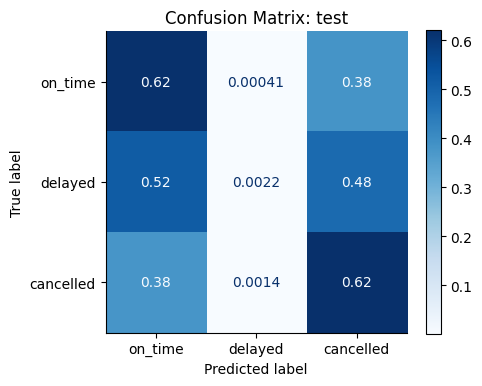

In [6]:
mf1_test, fig_test = evaluate(model, X_test, y_test, 'test')

## v1 through v4 Comparison

Did scale_pos_weight beat compute_sample_weight from v3?

               model  val macro F1  test macro F1
     v1 flights only        0.3054         0.2954
         v2 +weather        0.3641         0.3594
         v3 +weights        0.3750         0.3770
v4 +scale_pos_weight        0.2795         0.2614


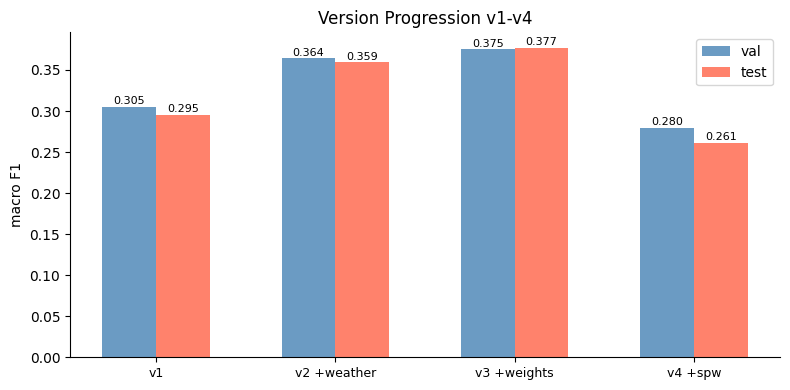

In [7]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights', 'v4 +scale_pos_weight'],
    'val macro F1':  [v1_val,  v2_val,  v3_val,  round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(8, 4))
x = np.arange(4)
width = 0.3
vals  = [v1_val,  v2_val,  v3_val,  mf1_val]
tests = [v1_test, v2_test, v3_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2 +weather', 'v3 +weights', 'v4 +spw'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Version Progression v1-v4')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

scale_pos_weight actually made things worse overall. Cancelled recall shot up but it completely destroyed delayed recall, the model just started flagging everything as cancelled. 

* The problem is multiclass doesn't work well with scale_pos_weight because you can't balance three classes at once this way.

The fix is to split into two separate binary models: one just for cancellations and one just for delays. That way scale_pos_weight can do its job properly without messing up everything else. That's v5.